# Budowa i podział zbioru danych (Dataset Creation)

W tym etapie następuje ostateczne przygotowanie danych do uczenia modeli uczenia maszynowego (KNN, SVM, CNN). Proces transformacji sygnału obejmuje przejście od ciągłych zapisów EKG do ustrukturyzowanych, poetykietowanych próbek (okien).

Główne założenia tego etapu:
1.  **Oknowanie (Windowing):** Podział sygnału na 10-sekundowe fragmenty z 5-sekundowym przesunięciem (overlap).
2.  **Etykietowanie (Labeling):** Zamiast usuwać zaszumione fragmenty, oznaczamy je jako klasę negatywną (Anomalia = 1). Sygnały poprawne otrzymują etykietę 0.
3.  **Normalizacja:** Skalowanie amplitudy sygnału do przedziału `[-1, 1]`, co jest kluczowe dla stabilności sieci neuronowych.
4.  **Podział (Splitting):** Wyodrębnienie zbiorów: Treningowego, Walidacyjnego i Testowego.

In [13]:

import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from pathlib import Path

file_path = "z4data.pkl"

# Wczytanie danych
if Path(file_path).exists():
    print(f"Wczytywanie danych z pliku: {file_path}...")
    with open(file_path, "rb") as f:
        data_package = pickle.load(f)
    
    # Pobieramy sygnały 
    raw_garmin = data_package.get("Watch")
    raw_clinical = data_package.get("ECG")
    
    print("✅ Dane wczytane pomyślnie.")
else:
    print(f"❌ BŁĄD: Plik {file_path} nie istnieje. Uruchom najpierw kod z z2.ipynb, aby wygenerować dane.")
    raw_garmin = None
    raw_clinical = None

Wczytywanie danych z pliku: z4data.pkl...
✅ Dane wczytane pomyślnie.


## 1. Definicja funkcji przetwarzających

Zaimplementowano trzy kluczowe funkcje operujące na surowych danych:

* **`create_windows`**: Odpowiada za pocięcie ciągłego sygnału na mniejsze wektory o ustalonej długości (1280 próbek dla 10 sekund przy 128 Hz).
* **`check_anomaly_label`**: Algorytm regułowy oceniający jakość sygnału. Okno otrzymuje etykietę **1 (Anomalia)**, jeśli spełnia którykolwiek z warunków:
    * Występują braki danych (NaN).
    * Sygnał jest "martwy" (odchylenie standardowe < 0.5).
    * Występują artefakty o niefizjologicznej amplitudzie (> 3000).
    * Wykryto nagłe, nienaturalne skoki wartości (> 2000).
* **`normalize_window`**: Wykonuje normalizację Min-Max według wzoru:
    $$x_{norm} = 2 \cdot \frac{x - x_{min}}{x_{max} - x_{min}} - 1$$
    Dzięki temu sygnały z różnych urządzeń (Garmin vs Aparatura) mają tę samą skalę amplitudową.

In [14]:
def create_windows(data, window_seconds=10, step_seconds=5, fs=128):    
    window_samples = int(window_seconds * fs) 
    step_samples = int(step_seconds * fs)     
    
    # Konwersja do numpy array, jeśli dane są w DataFrame/Series
    if hasattr(data, 'values'):
        data_array = data.values
    else:
        data_array = np.array(data)

    # Upewnienie się, że tablica jest odpowiedniego kształtu
    if data_array.ndim == 1:
        data_array = data_array.reshape(-1, 1)

    total_samples = data_array.shape[0]
    windows = []
    
    for start_index in range(0, total_samples - window_samples + 1, step_samples):
        end_index = start_index + window_samples
        window = data_array[start_index:end_index]
        windows.append(window)
        
    return np.array(windows)

def check_anomaly_label(window, threshold_max_amp=3000, threshold_min_std=0.5):
    
    if np.isnan(window).any():
        return 1
    
    # Sprawdzenie czy sygnał nie jest "martwy" 
    stds = np.std(window, axis=0)
    if (stds < threshold_min_std).all():
        return 1
            
    #Sprawdzenie artefaktów
    max_val = np.max(np.abs(window))
    if max_val > threshold_max_amp:
        return 1

    #Sprawdzenie nienaturalnych skoków
    diffs = np.diff(window, axis=0)
    if (np.abs(diffs) > 2000).any(): # orginalnie 1500
        return 1
        
    return 0 

def normalize_window(window):
    """
    Normalizacja Min-Max do przedziału [-1, 1].
    Wzór: 2 * (x - min) / (max - min) - 1
    """
    min_val = np.min(window)
    max_val = np.max(window)
    
    # Zabezpieczenie przed dzieleniem przez zero 
    if max_val - min_val == 0:
        return np.zeros_like(window)
        
    return 2 * (window - min_val) / (max_val - min_val) - 1

## 2. Generowanie zbioru rekordów

Poniższy kod iteruje przez wszystkie dostępne sygnały z obu źródeł (**Garmin** oraz **Kliniczne EKG**). Każde wycięte okno jest poddawane ocenie jakości i normalizacji, a następnie zapisywane wraz z metadanymi (ID, źródło) do struktury danych.

In [15]:
all_records = []

# Garmin
if raw_garmin is not None:
    print("Przetwarzanie sygnału Garmin...")
    windows_garmin = create_windows(raw_garmin)
    
    for i, window in enumerate(windows_garmin):
        label = check_anomaly_label(window)
        
        # Następnie normalizujemy do przedziału [-1, 1]
        normalized_signal = normalize_window(window)
        
        # Dodajemy do zbioru
        all_records.append({
            "ID_nagrania": f"Garmin_win_{i}",
            "sygnał": normalized_signal,   
            "źródło": "garmin",
            "label": label                 # 1 = anomalia, 0 = ok
        })

#dane kliniczne
if raw_clinical is not None:
    print("Przetwarzanie sygnału Klinicznego...")
    windows_clinical = create_windows(raw_clinical)
    
    for i, window in enumerate(windows_clinical):
        label = check_anomaly_label(window)
        normalized_signal = normalize_window(window)
        
        all_records.append({
            "ID_nagrania": f"Clinical_win_{i}",
            "sygnał": normalized_signal,
            "źródło": "kliniczne",
            "label": label
        })

print(f"✅ Zbudowano zbiór: {len(all_records)} rekordów.")

Przetwarzanie sygnału Garmin...
Przetwarzanie sygnału Klinicznego...
✅ Zbudowano zbiór: 254 rekordów.


## 3. Podział na zbiory (Train / Val / Test)

Utworzony zbiór danych jest dzielony na trzy niezależne części w proporcjach:
* **70% - Zbiór Treningowy:** Służy do nauki modelu.
* **15% - Zbiór Walidacyjny:** Służy do strojenia hiperparametrów i monitorowania procesu uczenia.
* **15% - Zbiór Testowy:** Służy do ostatecznej oceny skuteczności modeli.

Zastosowano **stratyfikację (`stratify`)**, aby zapewnić, że w każdym z podzbiorów udział procentowy anomalii i poprawnych sygnałów jest identyczny jak w zbiorze oryginalnym.

In [16]:
if all_records:
    # Tworzenie DataFrame
    df_dataset = pd.DataFrame(all_records)
    
    # Wyświetlenie statystyk
    print("\n--- STATYSTYKI ZBIORU ---")
    print("Liczba okien wg etykiety (0=Dobry, 1=Anomalia):")
    print(df_dataset['label'].value_counts())
    print("\nLiczba okien wg źródła:")
    print(df_dataset['źródło'].value_counts())

    # Podzial zbioru
    # treningowy (70%) reszta (30%)
    train_df, temp_df = train_test_split(
        df_dataset, 
        test_size=0.3, 
        random_state=42, 
        stratify=df_dataset['label'] # Ważne dla zachowania balansu klas
    )

    # Walidacja (15%)  Test (15%)
    val_df, test_df = train_test_split(
        temp_df, 
        test_size=0.5, 
        random_state=42, 
        stratify=temp_df['label']
    )
    
    print("\n--- ROZMIARY ZBIORÓW ---")
    print(f"Treningowy:  {len(train_df)} rekordów")
    print(f"Walidacyjny: {len(val_df)} rekordów")
    print(f"Testowy:     {len(test_df)} rekordów")

    # Sprawdzenie przykładowego rekordu
    sample = train_df.iloc[0]
    print(f"\nPrzykładowy rekord (ID: {sample['ID_nagrania']}):")
    print(f"Źródło: {sample['źródło']}")
    print(f"Label: {sample['label']}")
    print(f"Min sygnału: {np.min(sample['sygnał']):.2f}, Max sygnału: {np.max(sample['sygnał']):.2f}")
    
   

else:
    print("Brak danych do przetworzenia.")


--- STATYSTYKI ZBIORU ---
Liczba okien wg etykiety (0=Dobry, 1=Anomalia):
label
0    150
1    104
Name: count, dtype: int64

Liczba okien wg źródła:
źródło
kliniczne    249
garmin         5
Name: count, dtype: int64

--- ROZMIARY ZBIORÓW ---
Treningowy:  177 rekordów
Walidacyjny: 38 rekordów
Testowy:     39 rekordów

Przykładowy rekord (ID: Clinical_win_190):
Źródło: kliniczne
Label: 0
Min sygnału: -1.00, Max sygnału: 1.00


## Zapis do pliku


In [17]:
if all_records:
    print(f"\nPrzetworzono {len(all_records)} okien. Tworzę zbiory...")
    
    df = pd.DataFrame(all_records)
    
    # Podział na zbiory
    train, temp = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
    val, test = train_test_split(temp, test_size=0.5, random_state=42, stratify=temp['label'])
    
    # ZAPIS
    train.to_pickle("dataset_train.pkl")
    val.to_pickle("dataset_val.pkl")
    test.to_pickle("dataset_test.pkl")
    
    print("✅ SUKCES! Zapisano pliki oddzielnie na końcu:")
    print("   -> dataset_train.pkl")
    print("   -> dataset_val.pkl")
    print("   -> dataset_test.pkl")
else:
    print("⚠️ Nie utworzono plików, ponieważ lista rekordów jest pusta.")


Przetworzono 254 okien. Tworzę zbiory...
✅ SUKCES! Zapisano pliki oddzielnie na końcu:
   -> dataset_train.pkl
   -> dataset_val.pkl
   -> dataset_test.pkl


## 4. Weryfikacja wizualna (Visual Inspection)

W celu potwierdzenia poprawności automatycznego procesu etykietowania, przeprowadzono wyrywkową kontrolę jakości danych. Procedura weryfikacji polega na pobraniu i wyświetleniu:

1.  **3 losowych okien** ze zbioru, które algorytm zaklasyfikował jako sygnał poprawny (**Label = 0**).
2.  **3 losowych okien** ze zbioru, które algorytm uznał za anomalię (**Label = 1**).

Taka inspekcja pozwala szybko ocenić, czy do klasy "0" trafiają czytelne zapisy EKG, a do klasy "1" faktycznie trafiają sygnały uszkodzone, zaszumione lub płaskie linie.

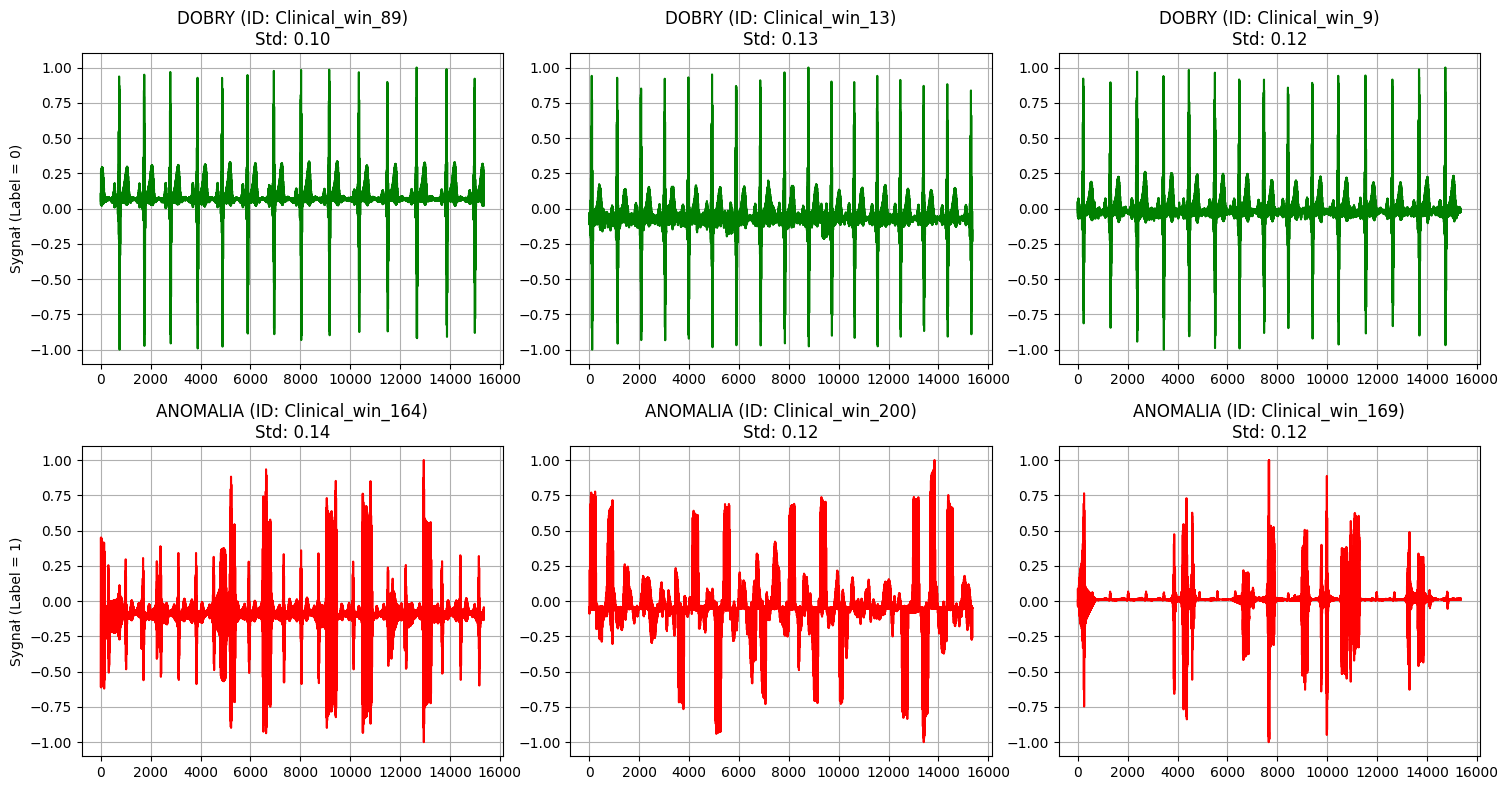

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_verification(df, n_samples=3):
    # Pobieramy losowe próbki z klasy 0 (Dobre) i 1 (Anomalie)
    good_samples = df[df['label'] == 0].sample(min(n_samples, len(df[df['label']==0])))
    bad_samples = df[df['label'] == 1].sample(min(n_samples, len(df[df['label']==1])))
    
    fig, axes = plt.subplots(nrows=2, ncols=n_samples, figsize=(15, 8))
    
    # Rysowanie dobrych sygnałów
    for i, (_, row) in enumerate(good_samples.iterrows()):
        sig = row['sygnał']
        # Jeśli sygnał jest spłaszczony (1D), to OK. Jeśli (N, 1), spłaszczamy.
        if sig.ndim > 1: sig = sig.flatten()
            
        axes[0, i].plot(sig, color='green')
        axes[0, i].set_title(f"DOBRY (ID: {row['ID_nagrania']})\nStd: {np.std(sig):.2f}")
        axes[0, i].set_ylim(-1.1, 1.1)
        axes[0, i].grid(True)
        
    # Rysowanie anomali
    for i, (_, row) in enumerate(bad_samples.iterrows()):
        sig = row['sygnał']
        if sig.ndim > 1: sig = sig.flatten()
            
        axes[1, i].plot(sig, color='red')
        axes[1, i].set_title(f"ANOMALIA (ID: {row['ID_nagrania']})\nStd: {np.std(sig):.2f}")
        axes[1, i].set_ylim(-1.1, 1.1)
        axes[1, i].grid(True)
    
    axes[0, 0].set_ylabel("Sygnał (Label = 0)")
    axes[1, 0].set_ylabel("Sygnał (Label = 1)")
    plt.tight_layout()
    plt.show()

# Wywołanie weryfikacji na zbiorze treningowym
if 'train_df' in locals():
    visualize_verification(train_df)
else:
    print("błąd")

### Wnioski z weryfikacji

Powyższe wykresy prezentują przykładowe okna zaklasyfikowane do obu grup.
* **Analiza poprawnych sygnałów (Zielone):** Potwierdza, że algorytm nie odrzuca okien o wysokiej amplitudzie, jeśli zachowują one charakterystykę EKG (widoczne załamki R).
* **Analiza anomalii (Czerwone):** Wskazuje, że do tej grupy trafiają sygnały o bardzo niskiej wariancji (odłączenie elektrody) lub zawierające nieregularne, wysokoczęstotliwościowe zakłócenia.

Na podstawie wizualnej oceny, przyjęte progi detekcji (`threshold_max_amp=3000`, `threshold_min_std=0.5`) uznaje się za wystarczające do generowania zbioru uczącego.